# CSI 5140 - Project #2
**Creator**: Janis Miroll, janismiroll@oakland.edu

**Project**: Implement and apply one model compression method on the CNN you built in Project 1, using the CIFAR-10 dataset. The model must be the one you developed in Project 1, but you can use any functions or libraries to implement your compression method. If you implement an existing compression method, include a link to the reference paper in both the introduction of your report and your presentation slides. If you develop a new approach, also note this in the same sections. 

## Description 

### 1. Evaluation Metrics

**Evaluation Metrics**: Calculate and report the following metrics for your compressed model.
1) Number of parameters
2) FLOPs
3) Training accuracy 
4) Test accuracy

### 2. Visualizations

Create visualizations to analyze the impact of model size on the final test accuracy. The y-axis should represent the final test accuracy. Customize the x-axis based on the compression method used:
* **For Pruning**: X-axis should be the remaining number of parameters after pruning.
* **For Knowledge Distillation (KD)**: X-axis should be the number of parameters for different student models.
* **For Quantization**: X-axis should be the bit-width of the quantized model, e.g., 1/2/3/4/8 bits


### 3. Ablation Study: 


Conduct a thorough ablation study to analyze the effects of different hyperparameters on the test accuracy or convergence speed of the compressed model. You are free to select what you want to analyze. Summarize key insights gained from these experiments. Your ablation study should include at least three different aspects (more aspects are encouraged).

## Implementation - Mainly from Project 1 taken

In [1]:
# Uncomment if not already installed in kernel
#!pip install torch torchvision numpy matplotlib

In [2]:
import torch
import torch.nn.functional as F
import numpy as np

print(torch.__version__)
torch.manual_seed(42)

2.10.0


In [3]:
device = torch.device("mps" if torch.mps.is_available() else "cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: mps


In [4]:
# ReLu
def ReLu(Z):
    return Z * (Z > 0)

In [5]:
# Softmax
def softmax(Z):
    shifted_Z = Z - torch.max(Z, dim = 0, keepdim = True).values
    exp = torch.exp(shifted_Z)
    return exp / torch.sum(exp, dim = 0, keepdim = True)

In [6]:
def cross_entropy_loss(A, y):
    batch_m = y.shape[0]
    log_probs = torch.log(A[y, torch.arange(batch_m)] + 1e-15)
    return - torch.sum(log_probs) / batch_m

In [7]:
def reg_L2(lambda_reg, y, *weights):
    batch_m = y.shape[0]
    penalty = 0
    for W in weights:
        penalty += torch.sum(W ** 2)
    return (lambda_reg / (2 * batch_m)) * penalty

In [8]:
def optimizer_step(params, opt_state, alpha, optimizer="sgd", beta1=0.9, beta2=0.99, eps=1e-8):
    """Updates params in-place. Works for sgd / momentum / rmsprop and adam"""
    opt_state["t"] += 1
    t = opt_state["t"]
    with torch.no_grad():
        for i, p in enumerate(params):
            grad = p.grad
            v = opt_state[i]["v"]
            s = opt_state[i]["s"]
            
            if optimizer == "sgd":
                p.data -= alpha * grad
            elif optimizer == "momentum":
                v.mul_(beta1).add_((1 - beta1) * grad)
                p.data -= alpha * v
            elif optimizer == "rmsprop":
                s.mul_(beta2).add_((1 - beta2) * grad * grad)
                p.data -= alpha * grad / (s.sqrt() + eps)
            elif optimizer == "adam":
                v.mul_(beta1).add_((1 - beta1) * grad)
                s.mul_(beta2).add_((1 - beta2) * grad * grad)
                # Bias correction
                v_cor = v / (1 - (beta1 ** t))
                s_cor = s / (1 - (beta2 ** t))
                p.data -= alpha * v_cor / (s_cor.sqrt() + eps)
            p.grad.zero_()
    

In [9]:
def learning_rate_decay(initial_lr, epoch, epochs, decay = "None"):
    """Updates Learning rate given the Decay method. Works for None, step, cosine, linear, inv_sqrt"""
    if decay == "None":
        return initial_lr
    elif decay == "step":
        if epoch < epochs // 3:
            return initial_lr
        elif epoch < 2 * epochs // 3:
            return 0.1 * initial_lr
        else:
            return 0.01 * initial_lr
    elif decay == "cosine":
        return 0.5 * initial_lr * (1 + torch.cos(torch.tensor(epoch * torch.pi / epochs)))
    elif decay == "linear":
        return max(initial_lr * (1 - (epoch / (epochs - 1))), 1e-6)
    elif decay == "inv_sqrt":
        return initial_lr / (epoch + 1) ** 0.5

In [10]:
def conv_forward(X, weight, b, pad, s):
    """
    Inputs:
        X: (N, C, H, W)             - batch of N images, C channels, spatial HxW
        weight: (Cp, C, Fh, Fw)     - Cp filters, each of shape CxFhxFw
        b: (Cp,)                    - One bias per output filter
        pad: int                    - zero-padding
        s: int             - stride
    """
    N, _ , H, W = X.shape
    Cp, _, Fh , Fw = weight.shape

    X_padded = F.pad(X, (pad, pad, pad, pad), value = 0) # X_padded: (N, C, H + 2*pad, W + 2*pad)
    X_col = F.unfold(X_padded, kernel_size = (Fh, Fw), stride = s) # X_col: (N, C*Fh*Fw , H_out * W_out)
    H_out = (H + 2*pad - Fh) // s + 1 # H_out: int
    W_out = (W + 2*pad - Fw) // s + 1 # W_out: int
    # L: H_out * W_out
    out = weight.flatten(1) @ X_col + b[None, :, None] # (Cp, C*Fh*Fw) @ (N, C*Fh*Fw, L) + (1, Cp, 1) → (N, Cp, L)

    return out.view(N, Cp, H_out, W_out) # (N, Cp, H_out, W_out)

In [11]:
def forward_pass(X, params, dropout=False, drop_p=0.1):
    W1, b1, W2, b2, W3, b3, W4, b4, W5, b5 = params
    Z1 = conv_forward(X, W1, b1, pad1, s1)
    A1 = ReLu(Z1)
    A1 = F.max_pool2d(A1, 2) # 32x32 -> 32x16x16

    Z2 = conv_forward(A1, W2, b2, pad2, s2)
    A2 = ReLu(Z2)
    A2 = F.max_pool2d(A2, 2) # 64x16 -> 64x8x8

    Z3 = conv_forward(A2, W3, b3, pad3, s3)
    A3 = ReLu(Z3)
    A3 = F.max_pool2d(A3, 2) # 128x8 -> 128x4x4


    A3 = A3.view(-1, n_h3p).T # Flatten and transpose before transition to FC layers

    # FC Layers

    Z4 = torch.mm(W4, A3) + b4
    A4 = ReLu(Z4)
    if dropout:
        mask = (torch.rand_like(A4) > drop_p).float()
        A4 = (A4 * mask) / (1 - drop_p)

    Z5 = torch.mm(W5, A4) + b5
    A5 = softmax(Z5)
    # Log correct predictions
    predictions = torch.argmax(A5, dim = 0)
    return A5, predictions

In [12]:
def eval_model_accuracy(dataloader, params):
    correct = 0
    total = 0
    with torch.no_grad():
        for data in dataloader:
            inputs, labels = data
            X = inputs.to(device)
            y = labels.to(device)
            _, predictions = forward_pass(X, params, dropout = False)
            correct += torch.sum(predictions == y).item()
            total += y.size(0)
    return correct / total

### Load Cifar10 dataset

In [13]:
from torchvision import datasets
from torchvision.transforms import v2
from torch.utils.data import DataLoader

In [14]:
# Augment dataset with torchvision.transforms
transforms = v2.Compose([
    v2.RandomCrop(32, padding = 4),
    v2.RandomHorizontalFlip(p = 0.5),
    v2.ColorJitter(brightness = 0.5, hue = 0.3),
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale = True),
    v2.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

In [15]:
train_set = datasets.CIFAR10(
    root='./data',
    train = True,
    download = True,
    transform = transforms)
train_loader = DataLoader(train_set, batch_size = 128, shuffle = True)

In [16]:
test_set = datasets.CIFAR10(
    root = './data/test',
    train = False,
    download = True,
    transform = v2.Compose([
        v2.ToImage(),
        v2.ToDtype(torch.float32, scale = True),
        v2.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ])
)
test_loader = DataLoader(test_set, batch_size=100, shuffle=False)

### Define Model Parameters & Hyperparameters

In [17]:
### Model Architecture

# Convolutional Layers
n_H1 = 32 # 32 pixels wide
n_W1 = 32 # 32 pixels wide
n_C1 = 3 # RGB Picture, hence 3 channels
f1 = 5 # Filter 1 size will be 5 x 5 x n_C1
n_C1p = 32 # Number of Filters in layer 1, n_C1prime
pad1 = 2 # Padding
s1 = 1 # Stride

n_H2 = ((n_H1 + 2 * pad1 - f1) // s1 + 1) // 2 # Pooling reduces the size of the image by a factor of 2
n_W2 = ((n_W1 + 2 * pad1 - f1) // s1 + 1) // 2
n_C2 = n_C1p
f2 = 3 # Filter 2 size
n_C2p = 64 # Number of Filters in layer 2, n_C2prime
pad2 = 1 # Padding
s2 = 1 # Stride

n_H3 = ((n_H2 + 2 * pad2 - f2) // s2 + 1) // 2 # Pooling reduces the size of the image by a factor of 2
n_W3 = ((n_W2 + 2 * pad2 - f2) // s2 + 1) // 2
n_C3 = n_C2p
f3 = 3 # Filter 2 size
n_C3p = 128 # Number of Filters in layer 3, n_C3prime
pad3 = 1 # Padding
s3 = 1 # Stride


# Fully Connected Layers
#n_x = 32 * 32 * 3 # Input size: 32 x 32 RGB images flattened to a 1D array
n_H3p = ((n_H3 + 2 * pad3 - f3) / s3 + 1) // 2 # Pooling
n_W3p = ((n_W3 + 2 * pad3 - f3) / s3 + 1) // 2
n_h3p = int(n_H3p * n_W3p * n_C3p) # Number of outputs from Conv layer to a 1D array
n_h4 = 256 # Number of neurons in the fourth hidden layer (FC)
n_output = 10 # 10 output classes for CIFAR10

### General Hyperparameters
learning_rate = 0.001
epochs = 50

### Regularization
regularization = True
if regularization:
    lambda_ = 0.01
dropout = True
drop_p4 = 0.1

### Optimizer
optimizer = "adam" # pick from "sgd", "momentum", "rmsprop" and "adam"
beta1 = 0.9
beta2 = 0.999
epsilon = 1e-8
lr_decay = "cosine" # pick from "None", "step", "cosine", "linear", "inv_sqrt"


In [18]:
def save_model(params, path):
    torch.save({
    'W1': params[0], 'b1': params[1],
    'W2': params[2], 'b2': params[3],
    'W3': params[4], 'b3': params[5],
    'W4': params[6], 'b4': params[7],
    'W5': params[8], 'b5': params[9],
}, path)

# Project 2 - Implementation start

Following the approach in: Deep Compression (2016, Han et. al)

https://arxiv.org/pdf/1510.00149

1) Magnitude Based Pruning

    - Retrain with Pruning Masks

2) Trained Quanitzation

    - Retrain the Codebook

3) NOT Covered: Huffman Coding
4) Evaluation & Visualization

## Initial Implementation, helper functions

### Load best model (c)

In [25]:
def load_model(path):
    state = torch.load(path, map_location=device)
    W1, b1 = state['W1'], state['b1']
    W2, b2 = state['W2'], state['b2']
    W3, b3 = state['W3'], state['b3']
    W4, b4 = state['W4'], state['b4']
    W5, b5 = state['W5'], state['b5']
    params = [W1, b1, W2, b2, W3, b3, W4, b4, W5, b5]
    return params

params = load_model("model_c.pth")
W1, b1, W2, b2, W3, b3, W4, b4, W5, b5 = params

### Baseline - Model Params, FLOPs, ...

In [26]:
def model_report(params, masks=None, codebooks=None, bits=None):
    """Per Layer and total summary"""
    W1, b1, W2, b2, W3, b3, W4, b4, W5, b5 = params
    weight_params = [W1, W2, W3, W4, W5]
    bias_params = [b1, b2, b3, b4, b5]

    W_out1 = H_out1 = (n_H1 + 2*pad1 - f1) // s1 + 1
    W_out2 = H_out2 = (n_H2 + 2*pad2 - f2) // s2 + 1
    W_out3 = H_out3 = (n_H3 + 2*pad3 - f3) // s3 + 1
    
    base_flops = [
        (W1.shape[1] * W1.shape[2] * W1.shape[3]) * W1.shape[0] * (W_out1 * H_out1) * 2,
        (W2.shape[1] * W2.shape[2] * W2.shape[3]) * W2.shape[0] * (W_out2 * H_out2) * 2,
        (W3.shape[1] * W3.shape[2] * W3.shape[3]) * W3.shape[0] * (W_out3 * H_out3) * 2,
        W4.shape[0] * W4.shape[1] * 2,
        W5.shape[0] * W5.shape[1] * 2
    ]
    
    total_bits = 0
    total_flops = 0
    total_non_zero = 0
    total_weights = 0

    for i, name in enumerate(["conv1", "conv2", "conv3", "fc4", "fc5"]):
        W, b = weight_params[i], bias_params[i]
        n_w, n_b = W.numel(), b.numel()
        nz = masks[i].bool().sum().item() if masks else n_w
        sparsity = 1 - nz / n_w
        flops = base_flops[i] * (nz / n_w)

        if codebooks: # After Quantization
            layer_bits = nz * bits[i] + len(codebooks[i]) * 32 + nz * 5 + n_b * 32
        elif masks: # After pruning
            layer_bits = nz * 32 + nz * 5 + n_b * 32
        else: # Baseline
            layer_bits = (n_w + n_b) * 32
        total_bits += layer_bits
        total_flops += flops
        total_non_zero += nz
        total_weights += n_w
    
    baseline_bits = sum((W.numel() + b.numel()) * 32 for W, b in zip(weight_params, bias_params))
    print(f"Total non-zero Parameters: {total_non_zero:,} / {total_weights:,}")
    print(f"Model size: {total_bits/8/1024:.2f} KB")
    print(f"Compression ratio: {baseline_bits / total_bits:.2f}x")
    print(f"FLOPS: {total_flops:,.0f}")

    train_acc = eval_model_accuracy(train_loader, params)
    test_acc = eval_model_accuracy(test_loader, params)
    print(f"Training Accuracy: {train_acc * 100:.2f}%")
    print(f"Test Accuracy: {test_acc * 100:.2f}%")
    
    return {
        "size_kb": total_bits/8/1024,
        "compression": baseline_bits / total_bits,
        "flops": total_flops,
        "train_acc": train_acc,
        "test_acc": test_acc}

In [27]:
baseline = model_report(params)

Total non-zero Parameters: 621,408 / 621,408
Model size: 2429.29 KB
Compression ratio: 1.00x
FLOPS: 24,843,264
Training Accuracy: 90.40%
Test Accuracy: 85.30%


### 1) Magnitude Based Pruning

In [28]:
def prune_weights(W, sparsity):
    """Set the smallest `sparsity` fraction of weights to zero."""
    flat = W.data.abs().flatten()
    threshold = torch.quantile(flat, sparsity)
    mask = (W.data.abs()) >= threshold.float()
    W.data *= mask
    return mask

In [29]:
def retrain_pruned(params, masks, epochs=20, learning_rate=0.0001):
    W1, b1, W2, b2, W3, b3, W4, b4, W5, b5 = params
    weight_params = [W1, W2, W3, W4, W5]

    opt_state = {}
    for i, p in enumerate(params):
        opt_state[i] = {"v": torch.zeros_like(p), "s": torch.zeros_like(p)}
    opt_state["t"] = 0

    for epoch in range(epochs):
        for data in train_loader:
            inputs, labels = data
            X = inputs.to(device)
            y = labels.to(device)
            A5, predictions = forward_pass(X, params, dropout=True, drop_p=0.1)
            J = cross_entropy_loss(A5, y)
            J.backward()
            optimizer_step(params, opt_state, alpha=learning_rate, optimizer='adam')
            with torch.no_grad():
                for W, m in zip(weight_params, masks):
                    W.data *= m
        print(f"Epoch {epoch}: Test accuracy = {eval_model_accuracy(test_loader, params)*100:.2f}%")

In [30]:
weight_params = [W1, W2, W3, W4, W5]
sparsities = [0.25, 0.25, 0.25, 0.75, 0.75] # 25% for conv layers and 75% for FC
masks = []
for W, sp in zip(weight_params, sparsities):
    m = prune_weights(W, sp)
    masks.append(m)

In [31]:
_ = model_report(params, masks)

Total non-zero Parameters: 202,632 / 621,408
Model size: 917.12 KB
Compression ratio: 2.65x
FLOPS: 18,105,600
Training Accuracy: 84.27%
Test Accuracy: 81.27%


In [32]:
FT_EPOCHS = 5

retrain_pruned(params, masks, epochs = FT_EPOCHS)


Epoch 0: Test accuracy = 84.10%
Epoch 1: Test accuracy = 84.15%
Epoch 2: Test accuracy = 84.23%
Epoch 3: Test accuracy = 84.37%
Epoch 4: Test accuracy = 84.28%


In [33]:
_ = model_report(params, masks)

Total non-zero Parameters: 202,632 / 621,408
Model size: 917.12 KB
Compression ratio: 2.65x
FLOPS: 18,105,600
Training Accuracy: 88.66%
Test Accuracy: 84.28%


### 2) Quantization

In [34]:
from sklearn.cluster import KMeans
def quantize_layer(W, mask, n_bits):
    """Quantize non zero weights into 2^n_bits clusters"""
    k = 2 ** n_bits
    nonzero = W.data[mask.bool()].cpu().numpy().reshape(-1, 1)

    init_centroids = np.linspace(nonzero.min(), nonzero.max(), k).reshape(-1, 1)
    kmean = KMeans(n_clusters=k, init=init_centroids, n_init=1)
    kmean.fit(nonzero)
    centroids = kmean.cluster_centers_.flatten()
    labels = kmean.labels_

    # Write centroids back into weight tensor
    W.data[mask.bool()] = torch.tensor(centroids[labels], dtype=W.dtype, device=W.device)
    
    # Full label matrix (-1 for pruned pos)
    label_matrix = torch.full(W.shape, -1, dtype=torch.long, device=W.device)
    label_matrix[mask.bool()] = torch.tensor(labels, dtype=torch.long, device=W.device)
    
    return torch.tensor(centroids, dtype=W.dtype, device=W.device), label_matrix

In [35]:
bits = [3, 3, 3, 3, 3] # Conv layer: 3 bit, FC layer: 3 bit
codebooks, label_matrices = [], []
for W, m, b in zip(weight_params, masks, bits):
    cb, lm = quantize_layer(W, m, b)
    codebooks.append(cb)
    label_matrices.append(lm)

In [36]:
_ = model_report(params, masks, codebooks, bits)

Total non-zero Parameters: 202,632 / 621,408
Model size: 199.95 KB
Compression ratio: 12.15x
FLOPS: 18,105,600
Training Accuracy: 78.82%
Test Accuracy: 79.64%


In [37]:
def retrain_codebook(params, masks, codebooks, label_matrices, epochs=20, lr=0.0001):
    W1, b1, W2, b2, W3, b3, W4, b4, W5, b5 = params
    weight_params = [W1, W2, W3, W4, W5]
    bias_params = [b1, b2, b3, b4, b5]
    for epoch in range(epochs):
        for data in train_loader:
            input, labels = data
            X, y = input.to(device), labels.to(device)
            A5, _ = forward_pass(X, params, dropout=True)
            J = cross_entropy_loss(A5, y)
            J.backward()
            with torch.no_grad():
                for W, m, cb, lm in zip(weight_params, masks, codebooks, label_matrices):
                    n_clusters = len(cb)
                    valid = lm >= 0 # non-pruned
                    cluster_ids = lm[valid]
                    grads = W.grad[valid]

                    grad_sums = torch.zeros(n_clusters, device=W.device)
                    grad_sums.scatter_add_(0, cluster_ids, grads)

                    cb -= lr *grad_sums
                    W.data[valid] = cb[cluster_ids]
                    W.grad.zero_()
                    
                for b in bias_params:
                    b.data -= lr*b.grad
                    b.grad.zero_()

        print(f"Epoch {epoch}: Test accuracy = {eval_model_accuracy(test_loader, params)*100:.2f}%")

In [38]:
retrain_codebook(params, masks, codebooks, label_matrices, epochs=FT_EPOCHS)

Epoch 0: Test accuracy = 81.13%
Epoch 1: Test accuracy = 81.37%
Epoch 2: Test accuracy = 81.30%
Epoch 3: Test accuracy = 81.66%
Epoch 4: Test accuracy = 81.51%


In [39]:
_ = model_report(params, masks, codebooks, bits)

Total non-zero Parameters: 202,632 / 621,408
Model size: 199.95 KB
Compression ratio: 12.15x
FLOPS: 18,105,600
Training Accuracy: 82.38%
Test Accuracy: 81.51%


## Ablation Study - Project 2

In [40]:
def deepCompression(sparsities, bits, ft_epochs, prune_only = False, quantize_only = False, lr=0.0001):
    """
    Run full compression pipeline
    prune -> fine tune -> quantize -> codebook retrain

    Args:
        sparsities: list of 5 floats, one per weight layer
        bits: list of 5 ints, quanitzation bit-width per layer
        ft_epochs: int, fine tuning epochs

    Returns:
    dict from model_report()
    """

    state = torch.load("model_c.pth", map_location=device)
    W1 = torch.nn.Parameter(state['W1'].clone())
    W2 = torch.nn.Parameter(state['W2'].clone())
    W3 = torch.nn.Parameter(state['W3'].clone())
    W4 = torch.nn.Parameter(state['W4'].clone())
    W5 = torch.nn.Parameter(state['W5'].clone())
    b1 = torch.nn.Parameter(state['b1'].clone())
    b2 = torch.nn.Parameter(state['b2'].clone())
    b3 = torch.nn.Parameter(state['b3'].clone())
    b4 = torch.nn.Parameter(state['b4'].clone())
    b5 = torch.nn.Parameter(state['b5'].clone())
    params = [W1, b1, W2, b2, W3, b3, W4, b4, W5, b5]
    weight_params = [W1, W2, W3, W4, W5]

    if prune_only:
        masks = [prune_weights(W, sp) for W, sp in zip(weight_params, sparsities)]
        retrain_pruned(params, masks, epochs=ft_epochs, learning_rate=lr)
        return model_report(params, masks), params

    elif quantize_only:
        masks = [torch.ones_like(W, dtype=torch.bool) for W in weight_params]
        codebooks, label_matrices = [], []
        for W, m, b in zip(weight_params, masks, bits):
            cb, lm = quantize_layer(W, m, b)
            codebooks.append(cb)
            label_matrices.append(lm)

        retrain_codebook(params, masks, codebooks, label_matrices, epochs=ft_epochs, lr=lr)

        return model_report(params, masks, codebooks, bits), params
    
    else:
        masks = [prune_weights(W, sp) for W, sp in zip(weight_params, sparsities)]
        retrain_pruned(params, masks, epochs=ft_epochs, learning_rate=lr)
        codebooks, label_matrices = [], []
        for W, m, b in zip(weight_params, masks, bits):
            cb, lm = quantize_layer(W, m, b)
            codebooks.append(cb)
            label_matrices.append(lm)

        retrain_codebook(params, masks, codebooks, label_matrices, epochs=ft_epochs, lr=lr)
        return model_report(params, masks, codebooks, bits), params

    

In [41]:
sp_prune_only = {}
for fc_sp in [0.25, 0.50, 0.75, 0.90, 0.95]:
    conv_sp = 0.33 * fc_sp
    print(f"Sparsity: conv: {conv_sp}; fc: {fc_sp}")
    sp_prune_only[fc_sp], _ = deepCompression(
        sparsities = [conv_sp, conv_sp, conv_sp, fc_sp, fc_sp],
        bits = [5, 5, 5, 5, 5],
        ft_epochs=5,
        prune_only=True
    )

Sparsity: conv: 0.0825; fc: 0.25
Epoch 0: Test accuracy = 85.03%
Epoch 1: Test accuracy = 84.79%
Epoch 2: Test accuracy = 84.96%
Epoch 3: Test accuracy = 85.02%
Epoch 4: Test accuracy = 84.95%
Total non-zero Parameters: 481,894 / 621,408
Model size: 2178.44 KB
Compression ratio: 1.12x
FLOPS: 22,616,960
Training Accuracy: 90.12%
Test Accuracy: 84.95%
Sparsity: conv: 0.165; fc: 0.5
Epoch 0: Test accuracy = 85.08%
Epoch 1: Test accuracy = 85.18%
Epoch 2: Test accuracy = 85.06%
Epoch 3: Test accuracy = 85.09%
Epoch 4: Test accuracy = 85.44%
Total non-zero Parameters: 342,381 / 621,408
Model size: 1548.31 KB
Compression ratio: 1.57x
FLOPS: 20,390,784
Training Accuracy: 89.99%
Test Accuracy: 85.44%
Sparsity: conv: 0.2475; fc: 0.75
Epoch 0: Test accuracy = 84.01%
Epoch 1: Test accuracy = 84.34%
Epoch 2: Test accuracy = 84.35%
Epoch 3: Test accuracy = 84.31%
Epoch 4: Test accuracy = 84.50%
Total non-zero Parameters: 202,868 / 621,408
Model size: 918.19 KB
Compression ratio: 2.65x
FLOPS: 18,164

In [42]:
bit_quantize_only = {}
for n_bits in [2, 3, 4, 5, 8]:
    print(f"Bits: {n_bits}")
    bit_quantize_only[n_bits], _ = deepCompression(
        sparsities = [0.25, 0.25, 0.25, 0.75, 0.75],
        bits = [n_bits] * 5,
        ft_epochs=5,
        quantize_only=True
    )

Bits: 2
Epoch 0: Test accuracy = 59.59%
Epoch 1: Test accuracy = 61.21%
Epoch 2: Test accuracy = 62.04%
Epoch 3: Test accuracy = 62.34%
Epoch 4: Test accuracy = 61.81%
Total non-zero Parameters: 621,408 / 621,408
Model size: 532.98 KB
Compression ratio: 4.56x
FLOPS: 24,843,264
Training Accuracy: 50.69%
Test Accuracy: 61.81%
Bits: 3
Epoch 0: Test accuracy = 77.20%
Epoch 1: Test accuracy = 77.30%
Epoch 2: Test accuracy = 77.74%
Epoch 3: Test accuracy = 77.55%
Epoch 4: Test accuracy = 77.67%
Total non-zero Parameters: 621,408 / 621,408
Model size: 608.91 KB
Compression ratio: 3.99x
FLOPS: 24,843,264
Training Accuracy: 76.06%
Test Accuracy: 77.67%
Bits: 4
Epoch 0: Test accuracy = 83.97%
Epoch 1: Test accuracy = 84.05%
Epoch 2: Test accuracy = 84.23%
Epoch 3: Test accuracy = 84.10%
Epoch 4: Test accuracy = 84.08%
Total non-zero Parameters: 621,408 / 621,408
Model size: 684.93 KB
Compression ratio: 3.55x
FLOPS: 24,843,264
Training Accuracy: 87.76%
Test Accuracy: 84.08%
Bits: 5
Epoch 0: Test 

In [43]:
sp_bit_results = {}
for fc_sp in [0.25, 0.50, 0.75, 0.90, 0.95]:
    conv_sp = 0.33 * fc_sp
    print(f"Sparsity: conv: {conv_sp}; fc: {fc_sp}")
    sp_bit_results[fc_sp], _ = deepCompression(
        sparsities = [conv_sp, conv_sp, conv_sp, fc_sp, fc_sp],
        bits = [5, 5, 5, 5, 5],
        ft_epochs=5
    )

Sparsity: conv: 0.0825; fc: 0.25
Epoch 0: Test accuracy = 85.05%
Epoch 1: Test accuracy = 85.19%
Epoch 2: Test accuracy = 85.09%
Epoch 3: Test accuracy = 84.95%
Epoch 4: Test accuracy = 84.90%
Epoch 0: Test accuracy = 84.56%
Epoch 1: Test accuracy = 84.63%
Epoch 2: Test accuracy = 84.58%
Epoch 3: Test accuracy = 84.58%
Epoch 4: Test accuracy = 84.64%
Total non-zero Parameters: 481,894 / 621,408
Model size: 590.79 KB
Compression ratio: 4.11x
FLOPS: 22,616,960
Training Accuracy: 89.63%
Test Accuracy: 84.64%
Sparsity: conv: 0.165; fc: 0.5
Epoch 0: Test accuracy = 84.89%
Epoch 1: Test accuracy = 85.13%
Epoch 2: Test accuracy = 85.13%
Epoch 3: Test accuracy = 85.02%
Epoch 4: Test accuracy = 85.16%
Epoch 0: Test accuracy = 84.75%
Epoch 1: Test accuracy = 84.82%
Epoch 2: Test accuracy = 84.83%
Epoch 3: Test accuracy = 84.75%
Epoch 4: Test accuracy = 84.68%
Total non-zero Parameters: 342,381 / 621,408
Model size: 420.48 KB
Compression ratio: 5.78x
FLOPS: 20,390,784
Training Accuracy: 89.63%
Te

In [44]:
ft_results = {}
for epoch in [1, 3, 5, 10, 20]:
    print(f"Fine-Tune Epoch: {epoch}")
    ft_results[epoch], _ = deepCompression(
        sparsities = [0.25, 0.25, 0.25, 0.75, 0.75],
        bits = [5, 5, 5, 5, 5],
        ft_epochs=epoch
    )

Fine-Tune Epoch: 1
Epoch 0: Test accuracy = 84.01%
Epoch 0: Test accuracy = 83.78%
Total non-zero Parameters: 202,632 / 621,408
Model size: 249.89 KB
Compression ratio: 9.72x
FLOPS: 18,105,600
Training Accuracy: 87.48%
Test Accuracy: 83.78%
Fine-Tune Epoch: 3
Epoch 0: Test accuracy = 83.91%
Epoch 1: Test accuracy = 84.05%
Epoch 2: Test accuracy = 84.22%
Epoch 0: Test accuracy = 84.03%
Epoch 1: Test accuracy = 83.95%
Epoch 2: Test accuracy = 84.06%
Total non-zero Parameters: 202,632 / 621,408
Model size: 249.89 KB
Compression ratio: 9.72x
FLOPS: 18,105,600
Training Accuracy: 87.99%
Test Accuracy: 84.06%
Fine-Tune Epoch: 5
Epoch 0: Test accuracy = 84.02%
Epoch 1: Test accuracy = 84.18%
Epoch 2: Test accuracy = 84.14%
Epoch 3: Test accuracy = 84.20%
Epoch 4: Test accuracy = 84.65%
Epoch 0: Test accuracy = 84.03%
Epoch 1: Test accuracy = 83.99%
Epoch 2: Test accuracy = 83.96%
Epoch 3: Test accuracy = 83.93%
Epoch 4: Test accuracy = 84.06%
Total non-zero Parameters: 202,632 / 621,408
Model 

### Evaluation & Plotting

In [49]:
import matplotlib.pyplot as plt # For evaluation
def plot_quantization(results, baseline_acc):
    fig, ax = plt.subplots()
    x = list(results.keys())
    y = [results[b]['test_acc'] * 100 for b in x]
    ax.plot(x, y, 's-', label = "Compression")
    ax.axhline(baseline_acc * 100, color = 'r', linestyle='--', label="Baseline (uncompressed)")
    ax.set_ylim(0, 100)
    ax.set_xlabel("Bit-width")
    ax.set_ylabel("Test Accuracy in %")
    ax.legend(loc='lower right')
    ax.grid(True)

def plot_prune(results, baseline_acc):
    fig, ax = plt.subplots()
    x = list(results.keys())
    y = [results[sp]['test_acc'] * 100 for sp in x]
    remaining = [(1 - s) * 100 for s in x]
    ax.plot(remaining, y, 's-', label = "Compressed")
    ax.axhline(baseline_acc * 100, color = 'r', linestyle='--', label="Baseline (uncompressed)")
    ax.set_ylim(0, 100)
    ax.set_xlabel("Remaining Parameters in %")
    ax.set_ylabel("Test Accuracy in %")
    ax.legend(loc='lower right')
    ax.grid(True)

def plot_results(*results, xlabel='', baseline_acc=None):
    fig, ax = plt.subplots()
    for i, (label, res) in enumerate(results):
        x = list(res.keys())
        y = [res[k]['test_acc'] * 100 for k in x]
        ax.plot(x, y, 's-', label=label)
    
    if baseline:
        ax.axhline(baseline_acc * 100, color = 'r', linestyle='--', label="Baseline (uncompressed)")
    ax.set_ylim(70, 90)
    ax.set_xlabel(xlabel)
    ax.set_ylabel("Test Accuracy in %")
    ax.legend(loc='lower right')
    ax.grid(True)


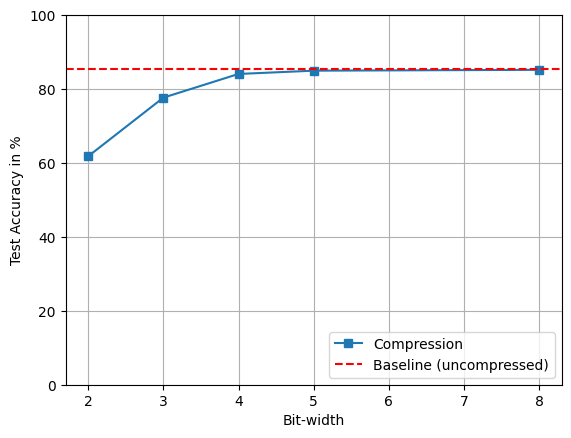

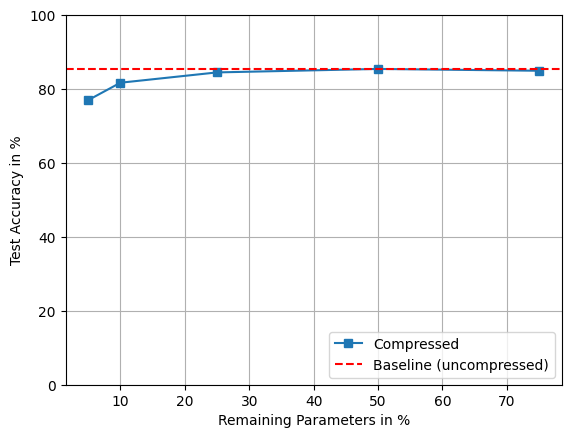

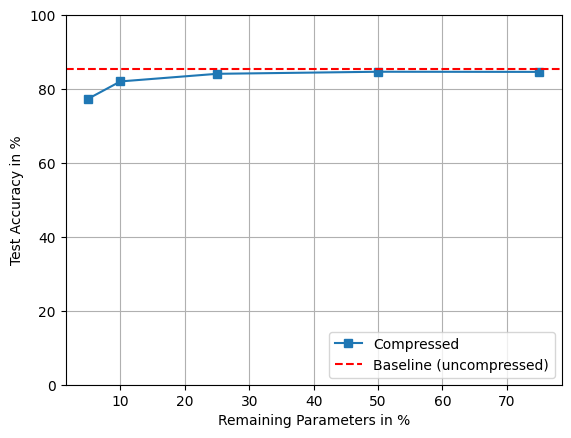

In [48]:

plot_quantization(bit_quantize_only, baseline['test_acc'])
plot_prune(sp_prune_only, baseline['test_acc'])

plot_prune(sp_bit_results, baseline['test_acc'])



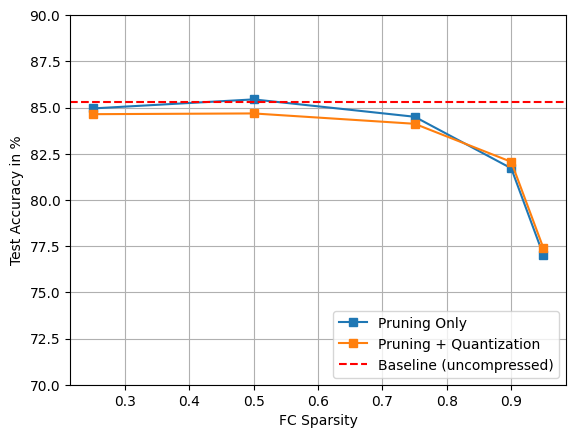

In [50]:
plot_results(
    ("Pruning Only", sp_prune_only),
    ("Pruning + Quantization", sp_bit_results),
    xlabel="FC Sparsity", baseline_acc=baseline['test_acc']
)

/var/folders/4s/7wdrk5991sz3r1r3tn44q5rc0000gn/T/ipykernel_79575/150121437.py:8: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


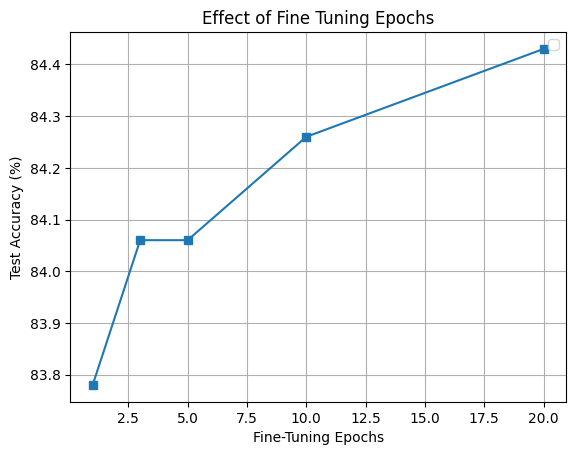

In [71]:
fig, ax = plt.subplots()
epochs = list(ft_results.keys())
acc = [ft_results[e]['test_acc'] * 100 for e in epochs]
ax.plot(epochs, acc, marker='s')
ax.set_xlabel("Fine-Tuning Epochs")
ax.set_ylabel("Test Accuracy (%)")
ax.set_title("Effect of Fine Tuning Epochs")
ax.legend()
ax.grid(True)
plt.tight_layout
plt.show()


### Inference Edge (Macbook M4 Pro) vs. GPU(A100 via Google Colab)

In [51]:
# Regenerate the best three models again for inference tests
# Prune Only:
_, params_prune_only = deepCompression(
        sparsities = [0.25, 0.25, 0.25, 0.75, 0.75],
        bits = [5, 5, 5, 5, 5],
        ft_epochs=5,
        prune_only=True
    )
save_model(params_prune_only, "model_pruned.pth")
# Quantize Only:
_, params_bit_only = deepCompression(
        sparsities = [0] * 5,
        bits = [4, 4, 4, 4, 4],
        ft_epochs=5,
        quantize_only=True
    )
save_model(params_bit_only, "model_bit.pth")
# Prune + Quantize:
_, params_combined = deepCompression(
        sparsities = [0.25, 0.25, 0.25, 0.75, 0.75],
        bits = [4, 4, 4, 4, 4],
        ft_epochs=5
    )
save_model(params_combined, "model_combined.pth")


Epoch 0: Test accuracy = 83.98%
Epoch 1: Test accuracy = 84.35%
Epoch 2: Test accuracy = 84.33%
Epoch 3: Test accuracy = 84.35%
Epoch 4: Test accuracy = 84.47%
Total non-zero Parameters: 202,632 / 621,408
Model size: 917.12 KB
Compression ratio: 2.65x
FLOPS: 18,105,600
Training Accuracy: 88.54%
Test Accuracy: 84.47%
Epoch 0: Test accuracy = 84.11%
Epoch 1: Test accuracy = 84.10%
Epoch 2: Test accuracy = 84.09%
Epoch 3: Test accuracy = 84.06%
Epoch 4: Test accuracy = 83.94%
Total non-zero Parameters: 621,408 / 621,408
Model size: 684.93 KB
Compression ratio: 3.55x
FLOPS: 24,843,264
Training Accuracy: 87.78%
Test Accuracy: 83.94%
Epoch 0: Test accuracy = 83.63%
Epoch 1: Test accuracy = 84.28%
Epoch 2: Test accuracy = 84.23%
Epoch 3: Test accuracy = 84.10%
Epoch 4: Test accuracy = 84.43%
Epoch 0: Test accuracy = 83.68%
Epoch 1: Test accuracy = 83.80%
Epoch 2: Test accuracy = 83.79%
Epoch 3: Test accuracy = 83.89%
Epoch 4: Test accuracy = 83.83%
Total non-zero Parameters: 202,632 / 621,408

In [ ]:
# Compare Inference time for the following three scenarios:
# 1) MacBook CPU
# 2) MacBook Metal
# 3) GPU (A100 Google Colab), number provided from separate notebook run to avoid switch of kernels.


import time

def benchmark_inference(params, dataloader, device, n_runs=3, label="Model"):
    params_dev = [p.to(device) for p in params]

    # Warmup
    with torch.no_grad():
        for data in dataloader:
            forward_pass(data[0].to(device), params_dev)
            break
    
    if device.type == 'mps':
        torch.mps.synchronize()
    elif device.type == 'cuda':
        torch.cuda.synchronize()

    times = []
    for _ in range(n_runs):
        start = time.perf_counter()
        with torch.no_grad():
            for data in dataloader:
                forward_pass(data[0].to(device), params_dev)
        if device.type == 'mps':
            torch.mps.synchronize()
        elif device.type == 'cuda':
            torch.cuda.synchronize()
        times.append(time.perf_counter() - start)
    avg = np.mean(times)
    ms_per_example = avg / len(dataloader.dataset) * 1000
    return avg, ms_per_example

params_base = load_model("model_c.pth")
params_prune = load_model("model_pruned.pth")
params_bit = load_model("model_bit.pth")
params_combined = load_model("model_combined.pth")

models = {
    "Baseline": params_base,
    "Pruned": params_prune,
    "Quantized": params_bit,
    "Combined": params_combined
}

results = {}
for dev in [torch.device("cpu"), torch.device("mps")]:
    for name, p in models.items():
        results[(name, str(dev))] = benchmark_inference(p, test_loader, dev, n_runs = 3, label = name)

In [ ]:
# Uncomment when trying CUDA version
#print(torch.cuda.is_available())
#for name, p in models.items():
#    results[(name, "cuda")] = benchmark_inference(p, test_loader, torch.device("cuda"), n_runs = 3, label = name)
#for (name, dev), (total, ms_per) in results.items():
#    if dev == "cuda":
#        print(f"{name}: total={total:.3f}, {ms_per:.4f}")

Results CUDA from separate run

In [66]:
cuda_results = {
    "Baseline": (3.287, 0.3359),
    "Pruned": (3.247, 0.3409),
    "Quantized": (3.357, 0.3392),
    "Combined": (3.321, 0.3389),
}
for name, val in cuda_results.items():
    results[(name, 'cuda')] = val

In [67]:
print(f"{'Model':<12} {'Device':<6} {'Total (s)':>10} {'ms/example':>12}")
print("-" * 44)

for i, ((name, dev), (total, ms_per)) in enumerate(results.items()):
    if i % 4 == 0:
        print("-"*44)
    print(f"{name:<12} {dev:<6} {total:>10.3f} {ms_per:>12.4f}")


Model        Device  Total (s)   ms/example
--------------------------------------------
--------------------------------------------
Baseline     cpu         2.834       0.2834
Pruned       cpu         2.805       0.2805
Quantized    cpu         2.788       0.2788
Combined     cpu         2.772       0.2772
--------------------------------------------
Baseline     mps         0.671       0.0671
Pruned       mps         0.638       0.0638
Quantized    mps         0.675       0.0675
Combined     mps         0.669       0.0669
--------------------------------------------
Baseline     cuda        3.287       0.3359
Pruned       cuda        3.247       0.3409
Quantized    cuda        3.357       0.3392
Combined     cuda        3.321       0.3389


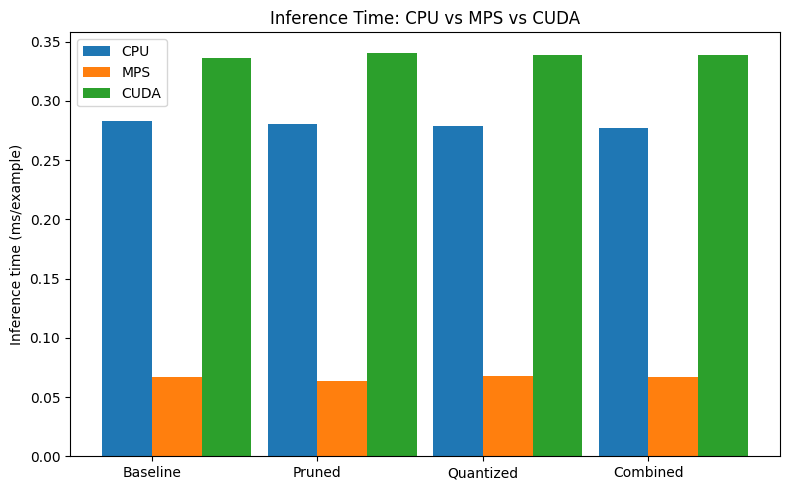

In [68]:
fig, ax = plt.subplots(figsize=(8,5))
model_names = list(models.keys())
devices = ['cpu', 'mps', 'cuda']
x = np.arange(len(model_names))
width = 0.3
for i, dev in enumerate(devices):
    times = [results[(m, dev)][1] for m in model_names]
    ax.bar(x + i * width, times, width, label=dev.upper())

ax.set_ylabel("Inference time (ms/example)")
ax.set_xticks(x + width / 2)
ax.set_xticklabels(model_names)
ax.legend()
ax.set_title("Inference Time: CPU vs MPS vs CUDA")
plt.tight_layout()
plt.show()
